# MSE StatDig : Chap 7 "Optimum filter"
## Ex 7.4 Kalman filter - Body in gravitation
ver : DLY/24.04.2026

## General

### Description

Let's assume that a body is ejected in the air with a constant velocity v = 10 [m/s] at a given angle $\alpha=40 degrees$

![filter](src/Body-Gravitation.png)

The goal is to estimate the trajectory (position(x,y)). The position (x,y) of the ball across time is measured but the measurment is very noisy. The goal is to filter the noise with the Kalman filter.

The dynmaic model of the system is given by the following equations:

$$
\begin{cases}
x[k] = x[k-1] + v_x[k-1] \cdot \Delta t \\
v_x[k] = v_x[k-1] \\
y[k] = y[k-1] + v_y[k-1] \cdot \Delta t + \frac{1}{2} a_y[k-1] \Delta t^2 \\
v_y[k] = v_y[k-1] + a_y[k-1] \cdot \Delta t \\
a_y[k] = a_y[k-1]
\end{cases}
$$

where the acceleration is the gravity $a_y[k] = -g = -9.81$.

Those equations can be written in matrix shape:

$$
\begin{bmatrix}
x[k] \\
v_x[k] \\
y[k] \\
v_y[k] \\
a_y[k]
\end{bmatrix}
=
\begin{bmatrix}
1 & \Delta t & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & \Delta t & \frac{1}{2} \Delta t^2 \\
0 & 0 & 0 & 1 & \Delta t \\
0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
x[k-1] \\
v_x[k-1] \\
y[k-1] \\
v_y[k-1] \\
a_y[k-1]
\end{bmatrix}
$$

And finally in the compact form:

$$
X[k] = F \cdot X[k-1]
$$

Where **F** is the transition matrix and **X[k]** is the current state, and **X[k−1]** is the previous state.

- The position (x, y) of the ball is measured in the presence of a disturbance **vn[k]**, where the noise is normally distributed with unit variance  
  $\mathcal{N}(0, R)$, where:

  $$
  R = \begin{bmatrix}
  \sigma_x^2 & 0 \\
  0 & \sigma_y^2
  \end{bmatrix}
  $$

  The measurement equation becomes:

  $$
  \begin{bmatrix}
  z_x[k] \\
  z_y[k]
  \end{bmatrix}
  =
  \begin{bmatrix}
  1 & 0 & 0 & 0 & 0 \\
  0 & 0 & 1 & 0 & 0
  \end{bmatrix}
  \begin{bmatrix}
  x[k] \\
  v_x[k] \\
  y[k] \\
  v_y[k] \\
  a_y[k]
  \end{bmatrix}
  + \textbf{vn}[k]
  $$

  And finally, in compact form:

  $$
  z[k] = H \cdot X[k] + \textbf{vn}[k]
  $$


- To generate the trajectory, the initial state also has to be defined:

  $$
  X[0] =
  \begin{bmatrix}
  x[0] \\
  v_x[0] \\
  y[0] \\
  v_y[0] \\
  a_y[0]
  \end{bmatrix}
  =
  \begin{bmatrix}
  0 \\
  v \cdot \cos(40^\circ) \\
  0 \\
  v \cdot \sin(40^\circ) \\
  -g
  \end{bmatrix}
  $$


### Work

#### Ex1 : Signal generation

- Generate the trajectory with the following code and display the trajectory and the measured trajectory:


```python
g  = 9.81    # [m/s^2] gravitation
v  = 10      # [m/s] initial speed
dt = 2e-3    # [s] sampling period
alpha = 40   # [°] ejection angle 
SigmaV = 0.2 # [m] standard deviation of the measurement noise
tmax = 2   # [s] Duration of the measurement
N = int(tmax//dt) # [-] Number of samples
n = np.arange(N)    # [-] numerical index
alpha = 40 # [°] initial angle
# measurement noise
np.random.seed(0)
noiseX = SigmaV * np.random.normal(0,1,N)
noiseY = SigmaV * np.random.normal(0,1,N)

F = np.array([[1,dt,0,0,0],
     [0,1 ,0,0,0],
     [0,0 ,1 ,dt,1/2*dt**2],
     [0,0,0,1 ,dt],
     [0,0,0,0,1]]) # Transition state matrix (A)
G = 0 # Input dynamic matrix (B)
H = np.array([[1,0,0,0,0],
     [0,0,1,0,0]]) # Observation matrix (C)

xHatInit = [0,v*np.cos(alpha/180*np.pi),0,v*np.sin(alpha/180*np.pi),-g] # initial state

# Trajectory generation
# genereate the trajectory
X = np.zeros((len(xHatInit),N));
X[:,0] = xHatInit;
for k in range(1,N):
   X[:,k] = np.dot(F,X[:,k-1])

x = X[0,:]; # get x position
y = X[2,:]; # get y position

# Add measurement noise
xnoise = x + noiseX;
ynoise = y + noiseY;

```

In [7]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt

In [8]:
g  = 9.81    # [m/s^2] gravitation
v  = 10      # [m/s] initial speed
dt = 2e-3    # [s] sampling period
alpha = 40   # [°] ejection angle 
SigmaV = 0.2 # [m] standard deviation of the measurement noise
tmax = 2   # [s] Duration of the measurement
N = int(tmax//dt) # [-] Number of samples
n = np.arange(N)    # [-] numerical index
alpha = 40 # [°] initial angle
# measurement noise
np.random.seed(0)
noiseX = SigmaV * np.random.normal(0,1,N)
noiseY = SigmaV * np.random.normal(0,1,N)

F = np.array([[1,dt,0,0,0],
     [0,1 ,0,0,0],
     [0,0 ,1 ,dt,1/2*dt**2],
     [0,0,0,1 ,dt],
     [0,0,0,0,1]]) # Transition state matrix (A)
G = 0 # Input dynamic matrix (B)
H = np.array([[1,0,0,0,0],
     [0,0,1,0,0]]) # Observation matrix (C)

xHatInit = [0,v*np.cos(alpha/180*np.pi),0,v*np.sin(alpha/180*np.pi),-g] # initial state
xHatInit = np.array(xHatInit)
# Trajectory generation
# genereate the trajectory
X = np.zeros((len(xHatInit),N));
X[:,0] = xHatInit;
for k in range(1,N):
   X[:,k] = np.dot(F,X[:,k-1])

x = X[0,:]; # get x position
y = X[2,:]; # get y position

# Add measurement noise
xnoise = x + noiseX;
ynoise = y + noiseY;

#
z = np.vstack((xnoise, ynoise))

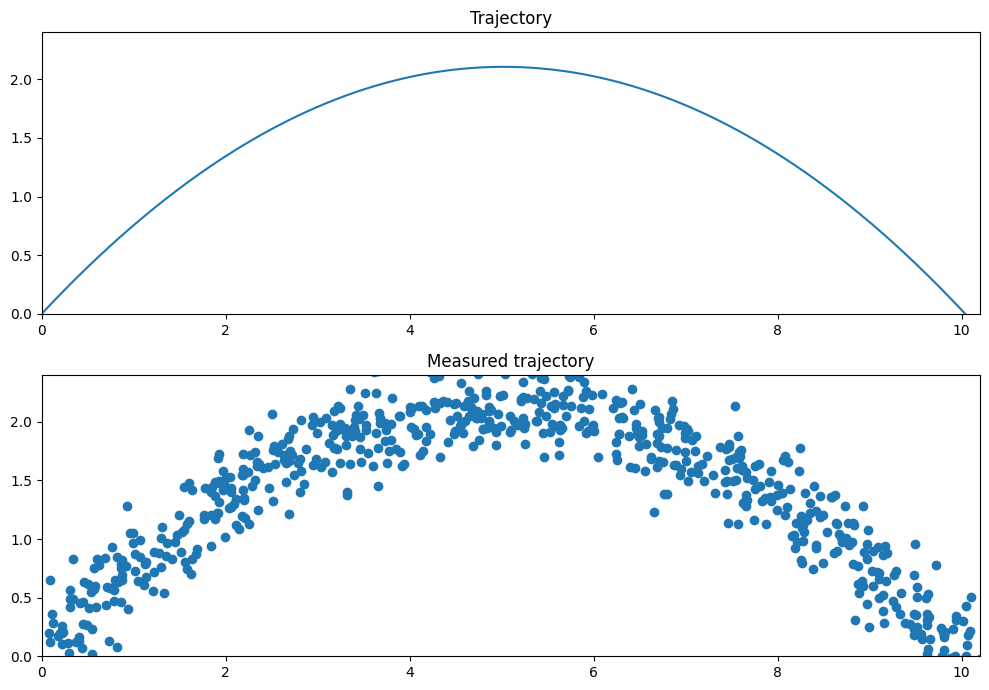

In [9]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(x, y)
plt.xlim(0, 10.2)
plt.ylim(0, 2.4)
plt.title('Trajectory')
fig.tight_layout()

ax2 = fig.add_subplot(2, 1, 2)      # initialize the bottom left Axes
ax2.plot(xnoise, ynoise, 'o')  # plot the bottom left graph
plt.xlim(0, 10.2)
plt.ylim(0, 2.4)
plt.title('Measured trajectory')
fig.tight_layout()

#### Ex2 : Kalman filter

##### Ex2.1 Kalman parameters

The Kalman filter needs the following parameters:

- F : Transition Matrix [p x p]
- H : Measurement Matrix [q x p]
- x(0|0) : Initial state [p x 1]
- z[k] : Measurement matrix [q x 1]
- Qw : Covariance matrix process noise [p x p]
- Qv : Covariance matrix measurement noise [q x q]
- P(0|0) : Covariance matrix error [p x p]

where p=5 is the number of state and q=2 is the number of measurement. 
Each of those matrices are known and were already defined during the trajectory generation except Qw, Qv and P(0|0).

- Build the remaining matrices :

In [10]:
# Measurement noise (R)
Qv = SigmaV**2 * np.eye(2)

# Process noise (Q)
sigma_w = 0.1
Qw = np.zeros((5,5))
Qw[4,4] = sigma_w**2

# Initial covariance
P0 = np.eye(5)

print("Qv=", Qv)
print("Qw=", Qw)
print("P(0|0)=", P0)

Qv= [[0.04 0.  ]
 [0.   0.04]]
Qw= [[0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.01]]
P(0|0)= [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


##### Ex2.2 Kalman recursivity

The following matrices are necessary to create the Kalman recursion, where the following matrices are computed:

- $\hat{X}[k|k-1]$: State estimation at sample k based on the measurement up to k-1 [$p \times 1$]  
- $P[k|k-1]$: Error covariance at sample k based on the measurement up to k-1 [$p \times p$]  
- $K[k]$: Kalman gain computed by minimizing the innovation (noise) on the measurement up to k [$p \times q$]  
- $P[k|k]$: Error covariance at sample k based on the measurement up to k [$p \times p$]  
- $\hat{X}[k|k]$: State estimation at sample k based on the measurement up to k [$p \times 1$]  

The calculation can be performed in two steps within a loop over each measured sample:

- **Prediction** (based on measurement samples from 1 to n-1):

  $$
  \hat{X}[k|k-1] = F \cdot \hat{X}[k-1|k-1]
  $$

  $$
  P[k|k-1] = F \cdot P[k-1|k-1] \cdot F^T + Q_w
  $$

- **Update** (based on n measurement samples and the innovation error):

  $$
  K[k] = P[k|k-1] \cdot H^T \cdot (H \cdot P[k|k-1] \cdot H^T + Q_v)^{-1}
  $$

  $$
  P[k|k] = (I - K[k] \cdot H) \cdot P[k|k-1]
  $$

  $$
  \hat{X}[k|k] = \hat{X}[k|k-1] + K[k] \cdot [z[k] - H \cdot \hat{X}[k|k-1]]
  $$


Your work :

- Build the function `KalmanGain` with **inputs**: `F`, `H`, `Qw`, `Qv`, `x(0|0)`, `P(0|0)`, `z[k]`  and with **outputs**: `K`, `X[k|k]`, `P[k|k]`, `X[k|k-1]`, `P[k|k-1]`.
- Compute the the filtered trajectory using the Kalman filter and display the result.
- Display the Kalman gain as well the error covariance matrix accross time

```python	
def KalmanGain(F, H, Qw, Qv, xHatInit, PInit, z):
    """
    Implements the stationary Kalman filter with:
    State equation       : x[n] = F * x[n-1] + w[n]
    Measurement equation : z[n] = H * x[n]   + v[n]

    Parameters:
    - F : [p x p] State transition matrix
    - H : [q x p] Measurement matrix
    - Qw : [p x p] Covariance matrix of process noise
    - Qv : [q x q] Covariance matrix of measurement noise
    - xHatInit : [p x 1] Initial state estimate
    - PInit : [p x p] Initial error covariance
    - z : [q x N] Measurement matrix (each column is a measurement vector)

    Returns:
    - K : [p x q x N] Kalman gain at each step
    - xHat : [p x N] State estimation at each step
    - P : [p x p x N] Error covariance at each step
    - Pn1 : [p x p x N] Error covariance at step k based on k-1
    - xHatn1 : [p x N] State prediction before measurement update
    """

    # your code here

    return K, xHat, P, Pn1, xHatn1
  ```

In [11]:
def KalmanGain(F, H, Qw, Qv, xHatInit, PInit, z):
    """
    Implements the stationary Kalman filter with:
    State equation       : x[n] = F * x[n-1] + w[n]
    Measurement equation : z[n] = H * x[n]   + v[n]

    Parameters:
    - F : [p x p] State transition matrix
    - H : [q x p] Measurement matrix
    - Qw : [p x p] Covariance matrix of process noise
    - Qv : [q x q] Covariance matrix of measurement noise
    - xHatInit : [p x 1] Initial state estimate
    - PInit : [p x p] Initial error covariance
    - z : [q x N] Measurement matrix (each column is a measurement vector)

    Returns:
    - K : [p x q x N] Kalman gain at each step
    - xHat : [p x N] State estimation at each step
    - P : [p x p x N] Error covariance at each step
    - Pn1 : [p x p x N] Error covariance at step k based on k-1
    - xHatn1 : [p x N] State prediction before measurement update
    """
    p = F.shape[0]      # taille de l'état
    q = H.shape[0]      # taille de la mesure
    N = z.shape[1]      # nombre d'instants

    # --- stockage ---
    xHat   = np.zeros((p, N))
    xHatn1 = np.zeros((p, N))
    P      = np.zeros((p, p, N))
    Pn1    = np.zeros((p, p, N))
    K      = np.zeros((p, q, N))
    I = np.eye(p)

    # --- initialisation (instant 0) ---
    xHat[:, 0] = xHatInit.flatten()
    P[:, :, 0] = PInit

    # --- boucle ---
    for k in range(1, N):
        # PRÉDICTION (k|k-1) : on avance depuis le tour précédent
        xHatn1[:, k] = F @ xHat[:, k-1]
        Pn1[:, :, k] = F @ P[:, :, k-1] @ F.T + Qw

        # MISE À JOUR (k|k) : on corrige avec la mesure z[:, k]
        K[:, :, k]   = Pn1[:, :, k] @ H.T @ np.linalg.inv(H @ Pn1[:, :, k] @ H.T + Qv)
        xHat[:, k]   = xHatn1[:, k] + K[:, :, k] @ (z[:, k] - H @ xHatn1[:, k])
        P[:, :, k]   = (I - K[:, :, k] @ H) @ Pn1[:, :, k]

    return K, xHat, P, Pn1, xHatn1

In [12]:
K, xHat, P, Pn1, xHatn1 = KalmanGain(F, H, Qw, Qv, xHatInit, P0, z)

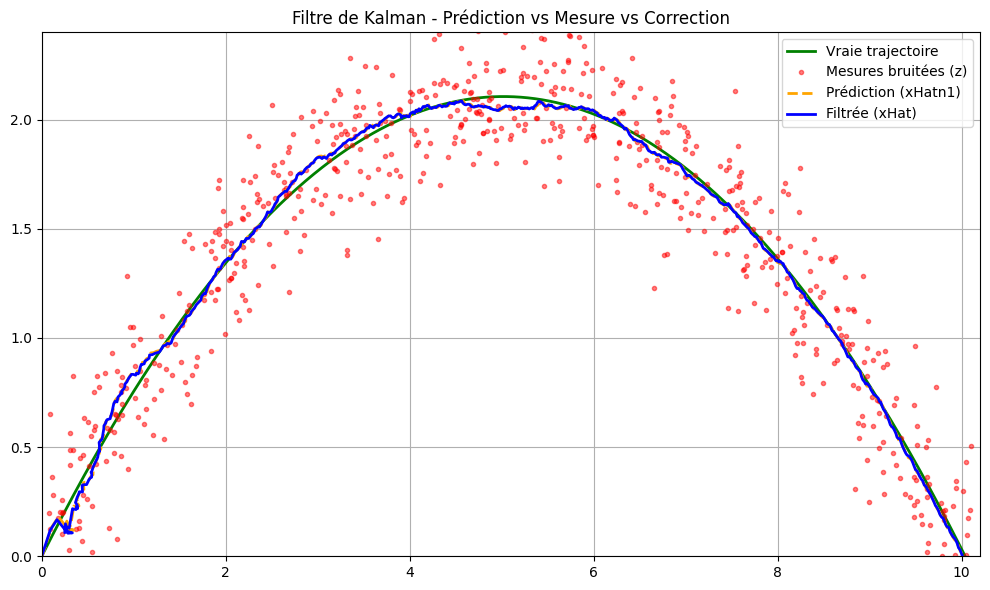

In [19]:
# --- Affichage des résultats (Comparaison complète) ---
fig = plt.figure(figsize=(10, 6))

# 1. Vraie trajectoire
plt.plot(x, y, label='Vraie trajectoire', color='green', linewidth=2)

# 2. Mesures bruitées (z)
plt.plot(xnoise, ynoise, 'o', markersize=3, alpha=0.5, label='Mesures bruitées (z)', color='red')

# 3. Trajectoire prédite (xHatn1) - AVANT correction
plt.plot(xHatn1[0, :], xHatn1[2, :], label='Prédiction (xHatn1)', color='orange', linestyle='--', linewidth=2)

# 4. Trajectoire filtrée (xHat) - APRÈS correction
plt.plot(xHat[0, :], xHat[2, :], label='Filtrée (xHat)', color='blue', linewidth=2)

plt.xlim(0, 10.2)
plt.ylim(0, 2.4)
plt.title('Filtre de Kalman - Prédiction vs Mesure vs Correction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

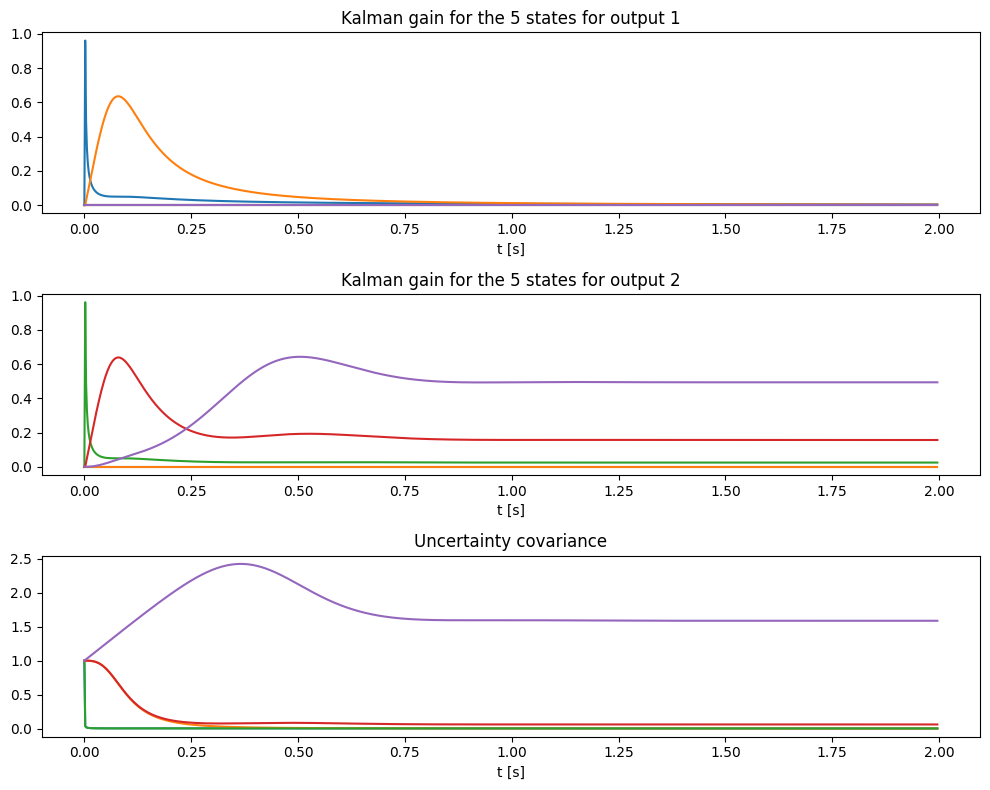

In [20]:
# Création de l'axe du temps (à partir de n et dt définis dans l'ex 1)
t = n * dt 

# Création de la figure avec 3 sous-graphiques
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# 1. Gain de Kalman pour la sortie 1 (x)
for i in range(5):
    axes[0].plot(t, K[i, 0, :])
axes[0].set_title('Kalman gain for the 5 states for output 1')
axes[0].set_xlabel('t [s]')

# 2. Gain de Kalman pour la sortie 2 (y)
for i in range(5):
    axes[1].plot(t, K[i, 1, :])
axes[1].set_title('Kalman gain for the 5 states for output 2')
axes[1].set_xlabel('t [s]')

# 3. Covariance de l'incertitude (diagonale de P)
for i in range(5):
    axes[2].plot(t, P[i, i, :])
axes[2].set_title('Uncertainty covariance')
axes[2].set_xlabel('t [s]')

# Ajustement des marges pour éviter que les titres ne se chevauchent
plt.tight_layout()
plt.show()